<a href="https://colab.research.google.com/github/Gabrimoura/Machine-Learning/blob/main/NLP_Text_Classification_Project_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple NLP Text Classification Project

**Goal:** Build a simple NLP text classification model using Python that automatically classifies new text into predefined categories.

**What this notebook covers (as required by the project brief):**
1. Basic data preprocessing
2. Text cleaning
3. Machine learning model training
4. Testing / evaluation
5. Prediction: new text can be entered and is automatically classified

**Categories:** `Technology`, `Sports`, `Health`, `Space`

**Dataset:** a small, balanced subset (about 2,400 real-world texts) of the public *20 Newsgroups* dataset, loaded directly from Scikit-learn. You can also use your own CSV (see Section 2).

**Tools:** Python, Pandas, NumPy, NLTK, Scikit-learn, Matplotlib, Seaborn

## 1. Setup and Imports

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
print("Setup complete.")

Setup complete.


## 2. Load the Dataset

Choose the data source in the cell below:

- `"newsgroups"` (default): downloads a public dataset and groups it into 4 categories.
- `"csv"`: upload your own file with two columns: `text` and `category`.

The dataset is balanced (same number of samples per category) and capped at `MAX_PER_CATEGORY`, which keeps the project small and fast.

In [ ]:
DATA_SOURCE = "newsgroups"      # change to "csv" to use your own file
MAX_PER_CATEGORY = 600          # keeps the dataset small and balanced
MAX_CHARS = 1500                # truncate very long texts for speed

if DATA_SOURCE == "newsgroups":
    CATEGORY_MAP = {
        "comp.graphics": "Technology",
        "comp.sys.ibm.pc.hardware": "Technology",
        "comp.sys.mac.hardware": "Technology",
        "rec.sport.baseball": "Sports",
        "rec.sport.hockey": "Sports",
        "sci.med": "Health",
        "sci.space": "Space",
    }
    raw = fetch_20newsgroups(
        subset="all",
        categories=list(CATEGORY_MAP.keys()),
        remove=("headers", "footers", "quotes"),   # avoids "cheating" with metadata
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    df = pd.DataFrame({
        "text": raw.data,
        "category": [CATEGORY_MAP[raw.target_names[i]] for i in raw.target],
    })

elif DATA_SOURCE == "csv":
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv(next(iter(uploaded)))[["text", "category"]]

# Basic dataset cleanup: remove empty / very short / duplicate texts
df = df.dropna()
df["text"] = df["text"].astype(str).str.strip().str.slice(0, MAX_CHARS)
df = df[df["text"].str.len() > 30].drop_duplicates(subset="text")

# Balance the dataset
df = pd.concat(
    [g.sample(min(len(g), MAX_PER_CATEGORY), random_state=RANDOM_STATE) for _, g in df.groupby("category")]
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2400, 2)


,text,category
0,You also have a severe problem with news heade...,Technology
1,is it possible to fit an FPU in a mac SE? (no...,Technology
2,"If gamma ray bursters are extragalactic, would...",Space
3,One last infield fly question that has always ...,Sports
4,I have a WANGTEK tape controller card (Revisio...,Technology


## 3. Exploratory Data Analysis

category
Technology    600
Space         600
Sports        600
Health        600
Name: count, dtype: int64

Missing values:
 text        0
category    0
dtype: int64


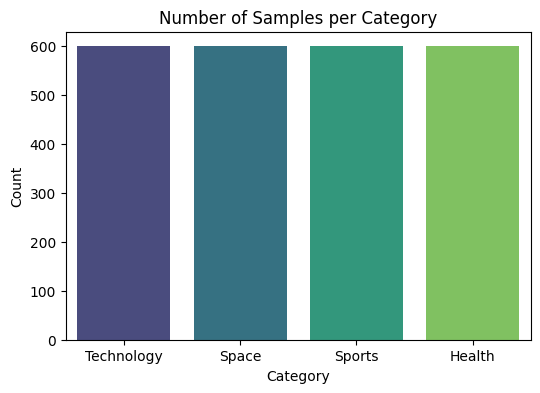

Average words per text: 109.6

Example text:
 You also have a severe problem with news headers.

FTP to cs.purdue.edu:pub/vanecek and pull proxima.tar.Z
and proxima.ps.Z.  Tres spif.

-- ...


In [ ]:
print(df["category"].value_counts())
print("\nMissing values:\n", df.isna().sum())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="category", palette="viridis")
plt.title("Number of Samples per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

df["word_count"] = df["text"].str.split().str.len()
print("Average words per text:", round(df["word_count"].mean(), 1))
print("\nExample text:\n", df["text"].iloc[0][:300], "...")

## 4. Text Cleaning and Preprocessing

Steps applied to every text:
1. Convert to lowercase
2. Remove URLs, e-mail addresses, numbers, punctuation and special characters
3. Remove English stop words (e.g. *the*, *is*, *and*)
4. Lemmatize words (e.g. *prices* -> *price*, *teams* -> *team*)

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)    # URLs
    text = re.sub(r"\S+@\S+", " ", text)             # e-mail addresses
    text = re.sub(r"[^a-z\s]", " ", text)             # keep letters only
    tokens = [lemmatizer.lemmatize(t) for t in text.split() if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(3)

,text,clean_text
0,You also have a severe problem with news heade...,also severe problem news header ftp purdue edu...
1,is it possible to fit an FPU in a mac SE? (no...,possible fit fpu mac plain old possible would ...
2,"If gamma ray bursters are extragalactic, would...",gamma ray burster extragalactic would absorpti...


## 5. Train / Test Split

80% of the data is used for training and 20% is kept for testing. `stratify` keeps the category proportions equal in both sets.

In [ ]:
X = df["clean_text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples: ", len(X_test))

Training samples: 1920
Testing samples:  480


## 6. Model Comparison (Cross-Validation)

Each model is a Scikit-learn `Pipeline`: **TF-IDF vectorizer -> classifier**. We compare three popular text classifiers with 5-fold stratified cross-validation on the training set.

In [ ]:
def make_pipeline(clf):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)),
        ("clf", clf),
    ])

models = {
    "Logistic Regression": make_pipeline(LogisticRegression(max_iter=1000, C=10, random_state=RANDOM_STATE)),
    "Complement Naive Bayes": make_pipeline(ComplementNB()),
    # Calibrated SVM so we can also show prediction confidence
    "Linear SVM": make_pipeline(CalibratedClassifierCV(LinearSVC(random_state=RANDOM_STATE), cv=3)),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    results[name] = scores.mean()
    print(f"{name:<24} CV accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")

best_name = max(results, key=results.get)
print(f"\nBest model: {best_name}")

Logistic Regression      CV accuracy: 0.908 (+/- 0.006)
Complement Naive Bayes   CV accuracy: 0.920 (+/- 0.013)
Linear SVM               CV accuracy: 0.909 (+/- 0.007)

Best model: Complement Naive Bayes


## 7. Hyperparameter Tuning

A small grid search on the best model to squeeze out extra accuracy.

In [ ]:
param_grids = {
    "Logistic Regression": {"clf__C": [1, 10, 50]},
    "Complement Naive Bayes": {"clf__alpha": [0.05, 0.1, 0.5, 1.0]},
    "Linear SVM": {"clf__estimator__C": [0.1, 0.5, 1, 5]},
}
grid_params = {**param_grids[best_name], "tfidf__ngram_range": [(1, 1), (1, 2)]}

grid = GridSearchCV(models[best_name], grid_params, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.3f}")

final_model = grid.best_estimator_

Best parameters: {'clf__alpha': 0.5, 'tfidf__ngram_range': (1, 1)}
Best CV accuracy: 0.925


## 8. Test the Final Model

In [ ]:
y_pred = final_model.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print("Classification report:\n")
print(classification_report(y_test, y_pred))

Test accuracy: 0.942

Classification report:

              precision    recall  f1-score   support

      Health       0.92      0.93      0.92       120
       Space       0.95      0.93      0.94       120
      Sports       0.98      0.98      0.98       120
  Technology       0.92      0.93      0.93       120

    accuracy                           0.94       480
   macro avg       0.94      0.94      0.94       480
weighted avg       0.94      0.94      0.94       480



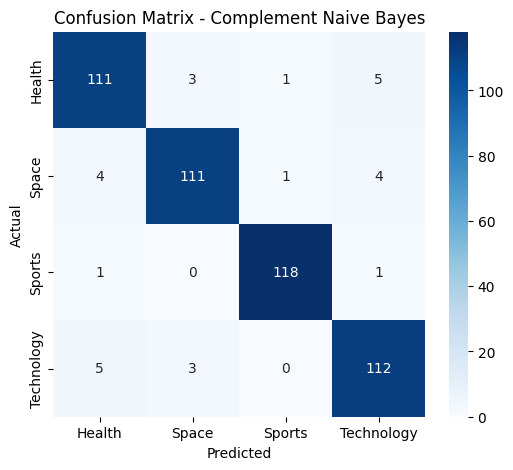

In [ ]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 9. Predict New Text

`predict_text()` cleans a new text and returns the predicted category with a confidence score for each class.

In [ ]:
def predict_text(text: str):
    cleaned = clean_text(text)
    if not cleaned:
        return {"prediction": None, "message": "Text is empty after cleaning. Try a longer sentence."}

    prediction = str(final_model.predict([cleaned])[0])
    probs = final_model.predict_proba([cleaned])[0]
    ranked = sorted(zip(final_model.classes_, probs), key=lambda x: x[1], reverse=True)
    return {
        "prediction": prediction,
        "confidence": {str(c): f"{p:.1%}" for c, p in ranked},
    }

examples = [
    "The goalie made 35 saves and the team won the game in overtime.",
    "My new graphics card has 8GB of memory and runs the latest games smoothly.",
    "The doctor prescribed a new medication to treat the infection and lower the fever.",
    "NASA plans to launch a new rocket to study the moon and send astronauts to orbit.",
]

for sentence in examples:
    print(f"Text: {sentence}")
    print(f"Result: {predict_text(sentence)}\n")

Text: The goalie made 35 saves and the team won the game in overtime.
Result: {'prediction': 'Sports', 'confidence': {'Sports': '91.9%', 'Technology': '3.0%', 'Space': '2.7%', 'Health': '2.4%'}}

Text: My new graphics card has 8GB of memory and runs the latest games smoothly.
Result: {'prediction': 'Technology', 'confidence': {'Technology': '70.3%', 'Sports': '13.9%', 'Space': '9.2%', 'Health': '6.5%'}}

Text: The doctor prescribed a new medication to treat the infection and lower the fever.
Result: {'prediction': 'Health', 'confidence': {'Health': '90.6%', 'Technology': '3.1%', 'Space': '3.1%', 'Sports': '3.1%'}}

Text: NASA plans to launch a new rocket to study the moon and send astronauts to orbit.
Result: {'prediction': 'Space', 'confidence': {'Space': '96.1%', 'Health': '1.6%', 'Technology': '1.3%', 'Sports': '1.0%'}}



### Interactive Classifier

Type any English text in the box below and click **Classify**.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

text_box = widgets.Textarea(
    placeholder="Type or paste a text here...",
    layout=widgets.Layout(width="90%", height="100px"),
)
button = widgets.Button(description="Classify", button_style="primary")
output_area = widgets.Output()

def on_click(_):
    output_area.clear_output()
    with output_area:
        result = predict_text(text_box.value)
        if result["prediction"] is None:
            print(result["message"])
        else:
            print(f"Predicted category: {result['prediction']}")
            print("Confidence:", result["confidence"])

button.on_click(on_click)
display(text_box, button, output_area)

Textarea(value='', layout=Layout(height='100px', width='90%'), placeholder='Type or paste a text here...')

Button(button_style='primary', description='Classify', style=ButtonStyle())

Output()

In [ ]:
# Alternative (simple console input) - uncomment to use:
# user_text = input("Enter a text to classify: ")
# print(predict_text(user_text))

## 10. Save and Reload the Model

In [ ]:
joblib.dump(final_model, "text_classifier.joblib")
print("Model saved as text_classifier.joblib")

loaded_model = joblib.load("text_classifier.joblib")
sample = clean_text("The pitcher threw a perfect game last night.")
print("Reloaded model prediction:", loaded_model.predict([sample])[0])

# To download the model to your computer from Colab:
# from google.colab import files
# files.download("text_classifier.joblib")

Model saved as text_classifier.joblib
Reloaded model prediction: Sports


## 11. Summary

**What was built:**
- A complete NLP text classification pipeline: preprocessing -> text cleaning -> TF-IDF -> ML model -> prediction
- Comparison of three algorithms with cross-validation, plus hyperparameter tuning
- Evaluation with accuracy, precision, recall, F1-score and a confusion matrix
- A reusable `predict_text()` function and an interactive box where new text is automatically classified
- A saved model (`.joblib`) that can be reused in other projects

**Using your own categories:** set `DATA_SOURCE = "csv"` in Section 2 and upload a file with `text` and `category` columns. Everything else runs unchanged.